#**유통 판매량 예측 및 재고 최적화**
## **단계3 : 모델링 및 비즈니스 평가**

# **0.미션**

* 단계1 다양한 모델링 수행
    * LSTM, CNN 등을 이용해서 다양한 시계열 모델링 수행
    * 성능 상위 2~3개 모델 선정
* 단계2 데이터 파이프라인 구축
    * test 데이터(raw data)로 부터 예측에 사용할 수 있는 형태로 데이터를 만드는 과정을 하나의 함수로 엮기
* 단계3 비즈니스 평가
    * 단계1에서 선정된 모델에 대해 test셋으로 평균 재고액 평가 수행

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
path = '/content/gdrive/Othercomputers/내 노트북/aivle6-practice/mini-project-6/'

### **(2) 라이브러리 설치 및 불러오기**

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

from keras.models import Sequential
from keras.backend import clear_session
from keras.layers import Input, Dense, LSTM, Conv1D, Flatten, Bidirectional, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [5]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [6]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

### **(3) 데이터 불러오기**

* **세부 요구사항**
    - 상품별로 저장한 데이터를 불러오시오.

In [7]:
df_bev = joblib.load(path+'data_beverage.pkl')

In [53]:
df_bev

,CustomerCount,Qty,WTI_Price,month,BAKERY,Home Appliances,Yogurt,2d_later,day_1,day_2,day_3,day_4,day_5,day_6,season_2,season_3,season_4
0,4422.0,9853.0,95.140000,1,1302.470,41.0,2991.0,15153.0,False,False,True,False,False,False,False,False,True
1,4167.0,8647.0,93.660000,1,1243.054,40.0,2694.0,15606.0,False,False,False,True,False,False,False,False,True
2,5341.0,15153.0,93.480000,1,1882.780,90.0,4355.0,7900.0,False,False,False,False,True,False,False,False,True
3,5123.0,15606.0,93.300000,1,2029.317,96.0,4228.0,7188.0,False,False,False,False,False,True,False,False,True
4,3917.0,7900.0,93.120000,1,992.359,33.0,2323.0,8800.0,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,3834.0,7856.0,53.610000,2,1389.665,30.0,2206.0,10208.0,False,True,False,False,False,False,False,False,True
1140,3955.0,8018.0,54.480000,2,1400.192,25.0,2099.0,12361.0,False,False,True,False,False,False,False,False,True
1141,4549.0,10208.0,53.990000,2,1743.020,32.0,2530.0,10108.0,False,False,False,True,False,False,False,False,True
1142,4619.0,12361.0,54.006667,2,2006.152,54.0,3341.0,10006.0,False,False,False,False,True,False,False,False,True


# **2.모델링**

* **세부 요구사항**
    * 3차원 데이터 구조 만들기
        * timestep 수는 적절한 간격으로 한가지 경우만 지정을 합니다.
    * LSTM, CNN 기반 초기 모델 생성
        * 성능 보다는 코드 틀을 작성하는데 집중합시다.
        * 노드 혹은 필터 수와 크기는 초기값으로 적절하게 지정해 봅시다.
    * 데이터 파이프라인 함수 작성하기
        * input : raw data
        * output : x_train, x_val, y_train, y_val
        * 원본 데이터에서 일부를 떼어 놓고, 파이프라인 함수를 테스트 해 봅시다.

In [9]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

## **(1) LSTM 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [93]:
y = df_bev['2d_later']
x = df_bev.drop(columns=['2d_later'])

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)  # x만 스케일링

x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

x_scaled, y = temporalize(x_scaled,y,60)

y = scaler.fit_transform(y.reshape(-1,1))
x_test, y_test = x_scaled[-60:], y[-60:]
x_train, y_train = x_scaled[:-60], y[:-60]


x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2)


print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (820, 60, 16)
x_val shape: (205, 60, 16)
x_test shape: (60, 60, 16)


In [94]:
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

* **모델링**

In [95]:
clear_session()

model_b = Sequential()
model_b.add(LSTM(256, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=True))
model_b.add(LSTM(64, return_sequences=True))
model_b.add(LSTM(16, return_sequences=True))
model_b.add(LSTM(4))

# 출력층
model_b.add(Dense(1))

model_b.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_b.summary()

hist = model_b.fit(x_train, y_train, epochs=300, batch_size=64, validation_data=(x_val, y_val), callbacks=[es]).history

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 256)             │         279,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 64)              │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60, 16)              │           5,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 4)                   │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 367,253 (1.40 MB)

 Trainable params: 367,253 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0415 - mae: 0.1617 - val_loss: 0.0234 - val_mae: 0.1210
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0196 - mae: 0.1119 - val_loss: 0.0217 - val_mae: 0.1139
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0183 - mae: 0.1089 - val_loss: 0.0211 - val_mae: 0.1108
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0178 - mae: 0.1082 - val_loss: 0.0219 - val_mae: 0.1043
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0182 - mae: 0.1097 - val_loss: 0.0217 - val_mae: 0.1159
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0185 - mae: 0.1126 - val_loss: 0.0205 - val_mae: 0.1066
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0187 - mae: 0.1104 - val_loss: 0.0207 - val_mae: 0.1058
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0156 - mae: 0.0995 - val_loss: 0.0200 - val_mae: 0.1062
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - lo

In [96]:
pred = model_b.predict(x_test)
pred = scaler.inverse_transform(pred)
y_test_org = scaler.inverse_transform(y_test)
pred = pd.DataFrame(pred)

print('MAE : ', mean_absolute_error(y_test_org, pred))
print('MAPE : ',mean_absolute_percentage_error(y_test_org, pred))
print('R2 : ',r2_score(y_test_org, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step
MAE :  2087.718912760417
MAPE :  0.17661753304251854
R2 :  0.4536186759524493


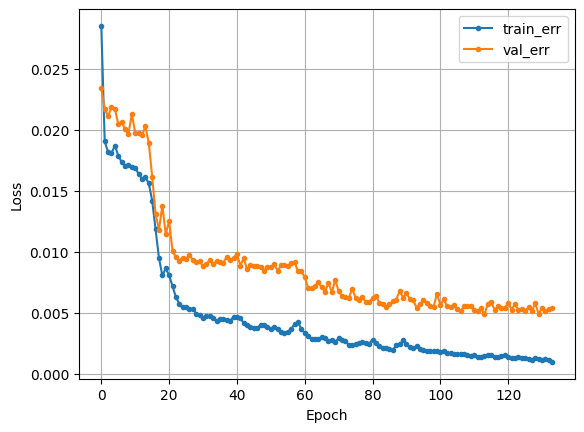

In [97]:
dl_history_plot(hist)

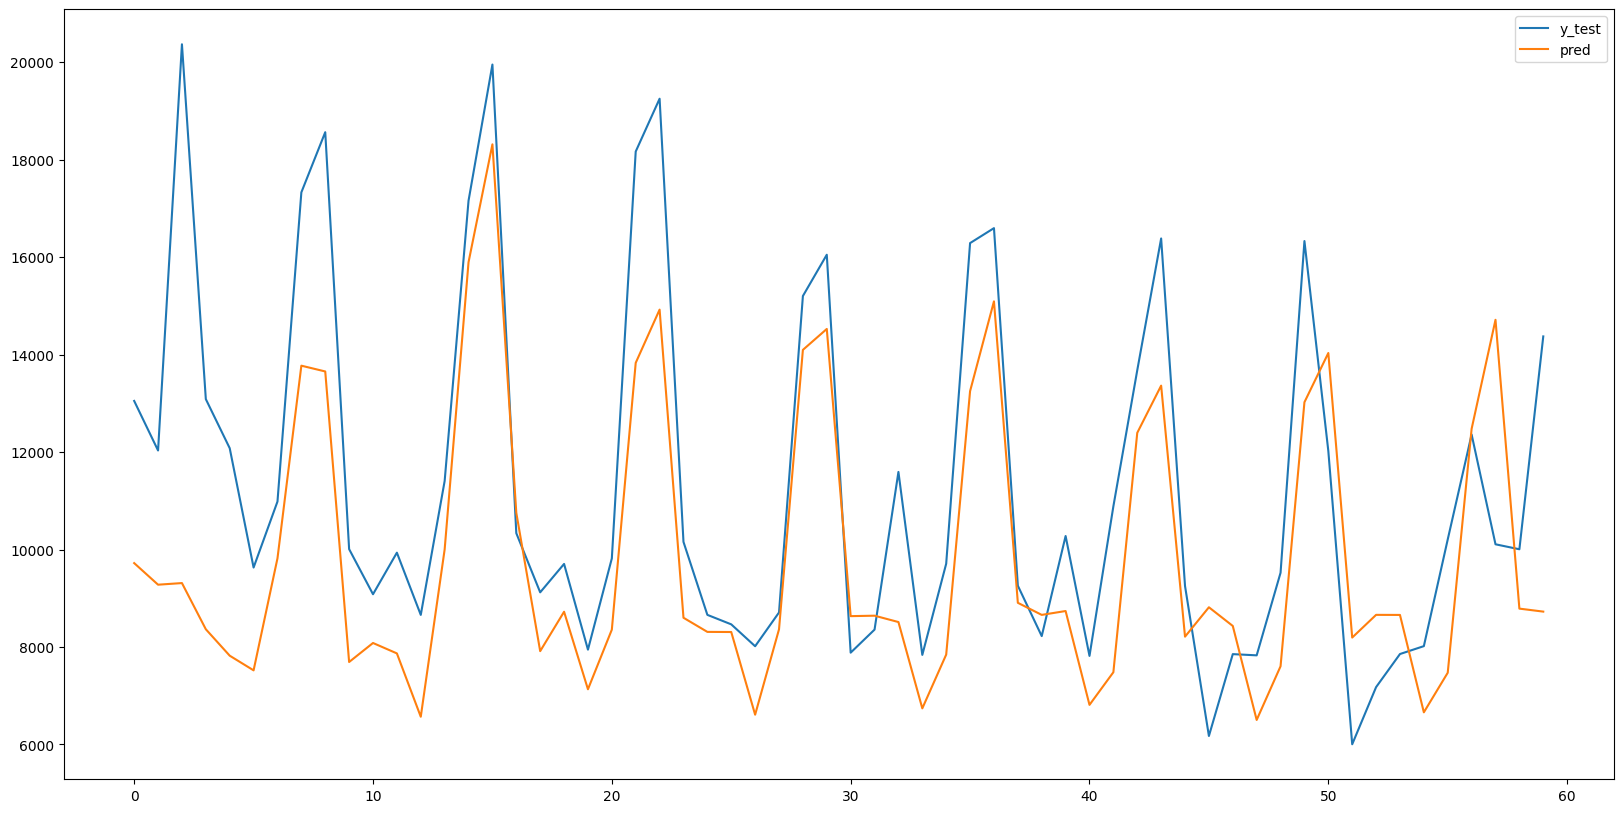

In [98]:
plt.figure(figsize=(20,10))
plt.plot(y_test_org,label='y_test')
plt.plot(pred,label='pred')
plt.legend()
plt.show()

### **2) 상품 : 12 - Milk**

* **데이터 준비**

* **모델링**

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

* **모델링**

## **(2) CNN 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [112]:
x = df_bev.drop(columns=['2d_later'])
y = df_bev['2d_later']
timesteps = 7

x, y = temporalize(x, y, timesteps)

num_samples = x.shape[0]
num_features = 2

numeric_data = x[:, :, :num_features].reshape(-1, num_features).astype(float)

scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)

scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

other_data = x[:, :, num_features:]

x = np.concatenate((scaled_numeric_data, other_data), axis=2)

In [113]:
x_train = x[:-60]
x_val = x[-60:]
y_train = y[:-60]
y_val = y[-60:]

x_train = x_train.astype(np.float32)
y_train = y_train.astype(np.float32)
x_val = x_val.astype(np.float32)
y_val = y_val.astype(np.float32)

* **모델링**

In [134]:
model_b2 = Sequential()
model_b2.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])))
model_b2.add(BatchNormalization())
model_b2.add(Conv1D(filters=16, kernel_size=3, activation='relu'))
model_b2.add(BatchNormalization())
model_b2.add(Conv1D(filters=4, kernel_size=3, activation='relu'))
model_b2.add(Flatten())

model_b2.add(Dense(1))

model_b2.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=50, restore_best_weights=True)

history = model_b2.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 86465920.0000 - mae: 8592.7354 - val_loss: 143254608.0000 - val_mae: 11382.4229
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 88131360.0000 - mae: 8675.6777 - val_loss: 143224464.0000 - val_mae: 11381.1045
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89485680.0000 - mae: 8713.3799 - val_loss: 143188992.0000 - val_mae: 11379.7441
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87009296.0000 - mae: 8613.2812 - val_loss: 143147120.0000 - val_mae: 11378.2227
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 85061880.0000 - mae: 8519.2285 - val_loss: 143063968.0000 - val_mae: 11375.0732
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83404808.0000 - mae: 8471.4648 - val_loss: 143017168.0000 - val_mae: 11373.4512
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 85357072.0000 - mae: 8520.6934 - val_loss: 142878064.0000 - val_mae: 11367.8330
Epoch 8/1000
34/34 

In [135]:
pred = model_b2.predict(x_val)

print('MAE : ', mean_absolute_error(y_val, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val, pred))
print('R2 : ',r2_score(y_val, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
MAE :  1544.4673
MAPE :  0.14099665
R2 :  0.673368513584137


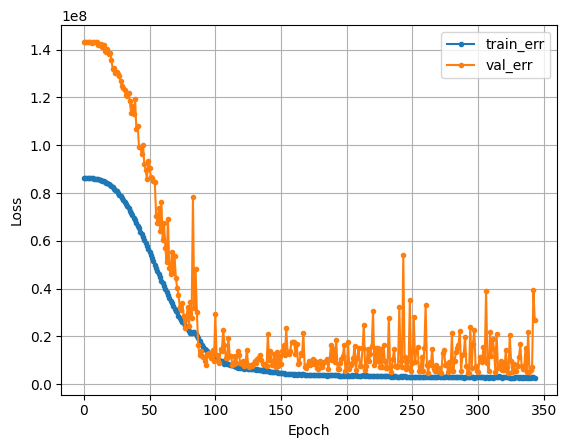

In [136]:
dl_history_plot(history)

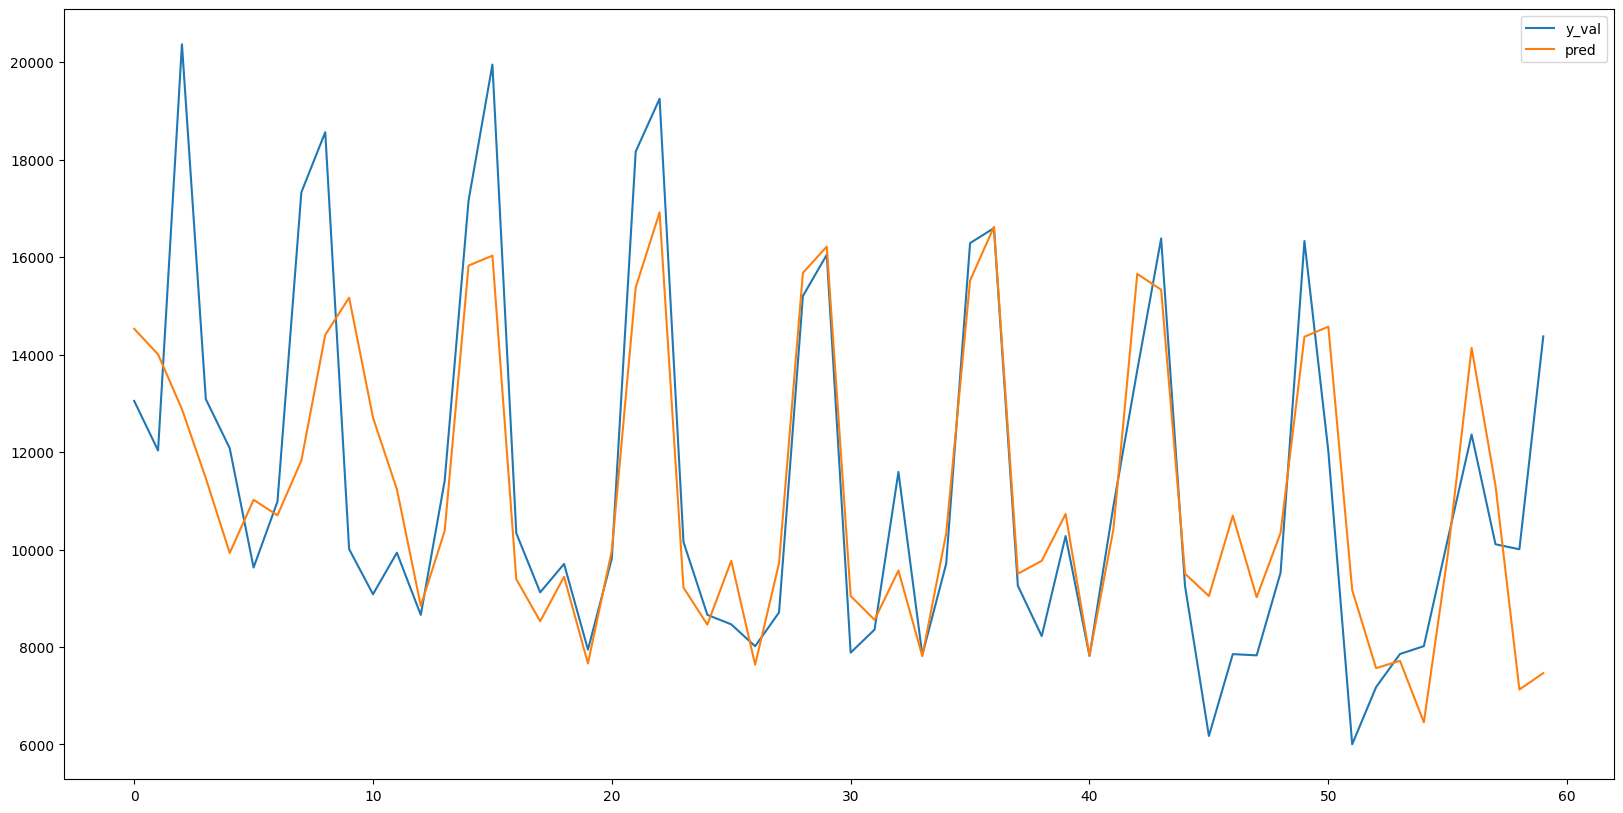

In [131]:
plt.figure(figsize=(20,10))
plt.plot(y_test_org,label='y_val')
plt.plot(pred,label='pred')
plt.legend()
plt.show()

### **2) 상품 : 12 - Milk**

* **데이터 준비**

* **모델링**

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

* **모델링**

# **3.데이터 파이프라인 생성**

* 세부 요구사항
    * 데이터 파이프라인 함수 작성하기
        * input : raw data(sales_test, orders_test, oil_price_test, products, stores)
        * output : x_test, y_test
        * test set으로 파이프라인 함수를 테스트 해 봅시다.

## **(1) 파이프라인 함수 생성**

## **(2) test 데이터로 확인**

* test용 데이터셋들 로딩

In [ ]:
oil_price_test = pd.read_csv(path + 'test/oil_price_test.csv')
orders_test = pd.read_csv(path + 'test/orders_test.csv')
sales_test = pd.read_csv(path + 'test/sales_test.csv')
products = pd.read_csv(path + 'test/products.csv')
stores = pd.read_csv(path + 'test/stores.csv')

sales_test['Date'] = pd.to_datetime(sales_test['Date'] )
oil_price_test['Date'] = pd.to_datetime(oil_price_test['Date'] )
orders_test['Date'] = pd.to_datetime(orders_test['Date'] )

In [ ]:
def preprocessing4predict([sales_test, ....], product_ID = 3, scaler = scaler, ....):



    return x_test, y_test

* 예측해보기

# **4.비즈니스 평가**

* 세부 요구사항
    * 기본 시뮬레이션 함수가 제공됩니다.
        * 필요하다면 해당 함수를 수정해서 사용할 수 있습니다.
    * 시뮬레이션 함수 사용하여 재고 평가
        * 실제값, 예측값, 안전재고 수량을 넣고 일평균 재고 금액을 확인합니다.
        * 기회손실수량은 0으로 맞추도록 안전재고 수량을 조절합니다.
        * 평균재고금액을 확인합니다.
    * 데이터는 test 셋을 이용합니다.
        * 예측 후 재고 평가 시, 스케일링된 y를 원래대로 돌려 놓아야 합니다.
            * y_real = y_sacled * (y_max - y_min) + y_min
            * pred_real = pred * (y_max - y_min) + y_min

## **(1) 재고 시뮬레이터**

In [ ]:
def inv_simulator(y, pred, safe_stock, price) :

    # 시뮬레이션 df 틀 만들기
    temp = pd.DataFrame({'y':y.reshape(-1,), 'pred':pred.reshape(-1,).round()})

    temp['base_stock'] = 0
    temp['close_stock'] = 0
    temp['order'] = 0
    temp['receive'] = 0

    # 시뮬레이션

    for i in range(len(temp)-2):  # 발주량은 leadtime 후 판매 예측량에 기초하므로 계산을 위해 마지막 leadtime 만큼의 행 제외
        if i == 0 : #첫 행. 2일 전 데이터가 없으므로,
            temp.loc[ i ,'receive'] = temp.loc[ i ,'y']  # 입고량은 실판매량으로 계산
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + safe_stock  # 기초재고는 실판매량 + 안전재고로 계산

        elif i == 1 : # 둘째 행, 2일 전 데이터가 없음.
            temp.loc[ i ,'receive'] = temp.loc[ i ,'y'] # 입고량은 실판매량으로 계산
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + temp.loc[ i-1 ,'close_stock']
        else :      # 나머지 전체 행.
            temp.loc[ i ,'receive'] = temp.loc[ i-2 ,'order']    # 입고량 = 2일전 발주량
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + temp.loc[ i-1 ,'close_stock']  # 기초재고 = 입고량 + 전날 기말재고

        # 기말재고 = 기초재고 - 판매량,  만약 0보다 작으면 0으로.
        stock = round(temp.loc[i, 'base_stock'] - temp.loc[i, 'y'])
        temp.loc[i, 'close_stock'] = np.where(stock> 0, stock, 0)

        # 발주량 = 2일후 판매예측량 + 안전재고 - 기말재고,  만약 주문량이 0보다 작으면 0
        order = temp.loc[i+2, 'pred'] + safe_stock - temp.loc[i, 'close_stock']
        temp.loc[i, 'order'] = np.where(order>0,order, 0)

    # 기회손실 = 만약 (기초재고 - 실판매량)이 0보다 작으면, 그만큼이 기회손실
    temp['lost'] = np.where((temp['base_stock'] - temp['y'])<0, (temp['base_stock'] - temp['y']),0).round()

    inventory = temp[:len(temp)-2]

    # 측정지표 계산
    DailyStock = ((inventory['base_stock'] + inventory['close_stock'])/2)
    DailyTurnover = (inventory['y'] + inventory['lost']) / DailyStock

    AvgDailyStock = round(DailyStock.mean(),3)
    AvgDailyStockAmt = AvgDailyStock * price
    turnover = round(DailyTurnover.mean(), 3)
    lost_sum = inventory['lost'].sum()


    print(f'일평균 재고량     : {AvgDailyStock}')
    print(f'일평균 재고 금액  : {AvgDailyStockAmt}')
    print(f'일평균 재고회전율 : {turnover}')
    print(f'기회손실 수량     : {lost_sum}')

    return inventory

## **(2) 예측 결과 시뮬레이션(재고금액 평가)**
